Khởi tạo thư viện, Database và Index

In [6]:
import pandas as pd
import chromadb
import time
import json
import numpy as np
import requests # Thêm thư viện requests để gọi Ollama API
from chromadb.utils import embedding_functions
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder

# --- 1. Load Ground Truth ---
gt_df = pd.read_excel(r'G:\Khoa_Luan\Source_code\backend\chunking\IUH_Retrival_Chatbot_GroundTruth.xlsx')
print(f"Đã tải {len(gt_df)} câu hỏi kiểm thử.")

# --- 2. Kết nối ChromaDB ---
chroma_client = chromadb.PersistentClient(path=r"G:\Khoa_Luan\Source_code\data\chroma_db") 
emb_fn = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
) 
collection = chroma_client.get_collection(name="camnang_iuh_collection", embedding_function=emb_fn)
print("Khởi tạo ChromaDB (Vector) thành công!")

# --- 3. Khởi tạo BM25 ---
all_data = collection.get(include=['documents', 'metadatas'])
corpus_chunks = all_data['documents']
corpus_urls = [m.get('source', '') for m in all_data['metadatas']]
tokenized_corpus = [doc.lower().split(" ") for doc in corpus_chunks]
bm25 = BM25Okapi(tokenized_corpus)
print(f"BM25 đã nạp xong {len(corpus_chunks)} chunks.")

# --- 4. Khởi tạo BGE Reranker ---
local_reranker = CrossEncoder('BAAI/bge-reranker-v2-m3')
print("BGE Reranker sẵn sàng!")

Đã tải 28 câu hỏi kiểm thử.
Khởi tạo ChromaDB (Vector) thành công!
BM25 đã nạp xong 518 chunks.


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

BGE Reranker sẵn sàng!


Các hàm lõi (RRF, Rerank) & Ollama Query Analyzer

In [7]:
def rrf_merge(list1_chunks, list1_urls, list2_chunks, list2_urls, k=60):
    """Gộp 2 danh sách bằng thuật toán Reciprocal Rank Fusion."""
    rrf_scores = {}
    chunk_to_url = {}
    
    def compute_rrf(chunks, urls):
        for rank, (chunk, url) in enumerate(zip(chunks, urls)):
            if chunk not in rrf_scores:
                rrf_scores[chunk] = 0
                chunk_to_url[chunk] = url
            rrf_scores[chunk] += 1 / (k + rank + 1)
            
    compute_rrf(list1_chunks, list1_urls)
    compute_rrf(list2_chunks, list2_urls)
    sorted_items = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return [item[0] for item in sorted_items], [chunk_to_url[item[0]] for item in sorted_items]

def local_rerank(query, documents, urls, top_n=3):
    """Lọc nhiễu và chấm điểm lại bằng Cross-Encoder."""
    if not documents: return [], []
    pairs = [[query, doc] for doc in documents]
    scores = local_reranker.predict(pairs)
    scored_docs = sorted(list(zip(scores, documents, urls)), key=lambda x: x[0], reverse=True)
    return [doc for score, doc, url in scored_docs[:top_n]], [url for score, doc, url in scored_docs[:top_n]]

# --- HÀM MỚI: GỌI OLLAMA ---
def analyze_query_ollama(user_query, model_name="qwen2:7b"): 
    """Sử dụng Ollama để sửa lỗi chính tả và phân rã truy vấn."""
    system_prompt = """Bạn là chuyên gia phân tích ngôn ngữ. Nhận câu hỏi, sửa lỗi chính tả/viết tắt, và tách thành các truy vấn tìm kiếm ngắn gọn.
    - Sửa lỗi chính tả (VD: "hk" -> "học kỳ", "sv" -> "sinh viên").
    - Nếu câu hỏi có nhiều ý, tách thành nhiều truy vấn (queries) riêng biệt.
    - Nếu vô nghĩa, gán is_valid = false.
    ĐẦU RA BẮT BUỘC LÀ JSON ĐÚNG ĐỊNH DẠNG SAU:
    {
      "is_valid": true,
      "original_intent": "câu hỏi đã sửa lỗi",
      "search_queries": ["truy vấn 1", "truy vấn 2"]
    }"""
    
    payload = {
        "model": model_name,
        "prompt": f"{system_prompt}\n\nCâu hỏi: {user_query}",
        "format": "json",
        "stream": False
    }
    
    try:
        response = requests.post("http://localhost:11434/api/generate", json=payload).json()
        result = json.loads(response['response'])
        # Đảm bảo có list search_queries
        if "search_queries" not in result or not result["search_queries"]:
            result["search_queries"] = [user_query]
        return result
    except Exception as e:
        print(f"Lỗi Ollama: {e}")
        # Fallback an toàn nếu LLM lỗi
        return {"is_valid": True, "original_intent": user_query, "search_queries": [user_query]}

# Hàm Helper chạy Hybrid cho 1 query bất kỳ (giúp tái sử dụng code)
def run_hybrid_rrf(query, top_k=15):
    # Vector
    v_res = collection.query(query_texts=[query], n_results=top_k)
    v_urls = [m.get('source', '') for m in v_res['metadatas'][0]]
    v_chunks = v_res['documents'][0]
    # Keyword
    tok_query = query.lower().split(" ")
    top_idx = np.argsort(bm25.get_scores(tok_query))[::-1][:top_k]
    k_urls = [corpus_urls[i] for i in top_idx]
    k_chunks = [corpus_chunks[i] for i in top_idx]
    
    return rrf_merge(v_chunks, v_urls, k_chunks, k_urls)

Định nghĩa 6 Baselines

In [8]:
# 1. BASELINE 1: Chỉ dùng Vector
def b1_vector(query, k=3):
    start = time.time()
    res = collection.query(query_texts=[query], n_results=k)
    return {"urls": [m.get('source', '') for m in res['metadatas'][0]], "latency": time.time() - start}

# 2. BASELINE 2: Chỉ dùng Keyword (BM25)
def b2_keyword(query, k=3):
    start = time.time()
    tok_query = query.lower().split(" ")
    top_idx = np.argsort(bm25.get_scores(tok_query))[::-1][:k]
    return {"urls": [corpus_urls[i] for i in top_idx], "latency": time.time() - start}

# 3. BASELINE 3: Hybrid Thuần (Chỉ gộp, KHÔNG lọc nhiễu)
def b3_hybrid_no_rerank(query, k=3):
    start = time.time()
    m_chunks, m_urls = run_hybrid_rrf(query, top_k=10)
    return {"urls": m_urls[:k], "latency": time.time() - start}

# 4. BASELINE 4: Hybrid Tối ưu (Gộp + Lọc nhiễu Reranker)
def b4_hybrid_rerank(query, k_initial=15, k_final=3):
    start = time.time()
    m_chunks, m_urls = run_hybrid_rrf(query, top_k=k_initial)
    f_chunks, f_urls = local_rerank(query, m_chunks, m_urls, top_n=k_final)
    return {"urls": f_urls, "latency": time.time() - start}

# --- NEW: 5. BASELINE 5: Query Analyzer + Hybrid (Không Rerank) ---
def b5_analyzer_hybrid_no_rerank(query, final_k=3):
    start = time.time()
    analysis = analyze_query_ollama(query)
    
    if not analysis.get("is_valid", True):
        # Fallback về search bình thường thay vì trả về rỗng để cứu Recall
        return b3_hybrid_no_rerank(query, k=final_k) 
    
    global_scores = {}
    
    # Chấm điểm RRF cho TẤT CẢ sub-queries
    for sq in analysis["search_queries"]:
        m_chunks, m_urls = run_hybrid_rrf(sq, top_k=5)
        for rank, url in enumerate(m_urls):
            if url not in global_scores:
                global_scores[url] = 0
            global_scores[url] += 1 / (60 + rank + 1) # Cộng dồn điểm RRF từ các sub-query
            
    # Sắp xếp lại lấy top cuối cùng
    sorted_urls = [item[0] for item in sorted(global_scores.items(), key=lambda x: x[1], reverse=True)]
    
    return {"urls": sorted_urls[:final_k], "latency": time.time() - start}

# --- NEW: 6. BASELINE 6: Query Analyzer + Hybrid + Rerank ---
def b6_analyzer_hybrid_rerank(query, final_k=3):
    start = time.time()
    analysis = analyze_query_ollama(query)
    
    if not analysis.get("is_valid", True):
        return b4_hybrid_rerank(query, k_final=final_k)
        
    global_rerank_scores = {}
    
    for sq in analysis["search_queries"]:
        m_chunks, m_urls = run_hybrid_rrf(sq, top_k=10)
        
        # Rerank ngay bằng chính sub-query này
        pairs = [[sq, doc] for doc in m_chunks]
        scores = local_reranker.predict(pairs)
        
        for score, url in zip(scores, m_urls):
            # Nếu URL này được tìm thấy ở nhiều sub-query, giữ lại điểm Rerank cao nhất
            if url not in global_rerank_scores or score > global_rerank_scores[url]:
                global_rerank_scores[url] = score
                
    # Sắp xếp theo điểm Rerank cao nhất
    sorted_urls = [item[0] for item in sorted(global_rerank_scores.items(), key=lambda x: x[1], reverse=True)]
    
    return {"urls": sorted_urls[:final_k], "latency": time.time() - start}

In [9]:
evaluation_logs = []
print("BẮT ĐẦU CHẠY KIỂM THỬ 6 CHIẾN LƯỢC ĐỐI CHỨNG...")

for index, row in gt_df.iterrows():
    query = row['Query']
    true_tier = row['Tier']
    expected_urls = row['Expected_Source_URLs']
    
    print(f"Đang xử lý [{index+1}/{len(gt_df)}] (Tier {true_tier}): {query[:40]}...")
    
    res_1 = b1_vector(query)
    res_2 = b2_keyword(query)
    res_3 = b3_hybrid_no_rerank(query)
    res_4 = b4_hybrid_rerank(query)
    res_5 = b5_analyzer_hybrid_no_rerank(query)
    res_6 = b6_analyzer_hybrid_rerank(query)
    
    log_entry = {
        "query_id": index + 1,
        "true_tier": true_tier,
        "expected_urls": expected_urls,
        "b1": res_1, "b2": res_2, "b3": res_3, "b4": res_4, "b5": res_5, "b6": res_6
    }
    evaluation_logs.append(log_entry)

with open('retrieval_experiment_logs_V4.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_logs, f, ensure_ascii=False, indent=4)

print("HOÀN TẤT! Đã lưu log V4.")

BẮT ĐẦU CHẠY KIỂM THỬ 6 CHIẾN LƯỢC ĐỐI CHỨNG...
Đang xử lý [1/28] (Tier 1): Trường Đại học Công nghiệp TP.HCM có nhữ...
Đang xử lý [2/28] (Tier 1): Điểm TOEIC 4 kỹ năng tối thiểu là bao nh...
Đang xử lý [3/28] (Tier 1): Tài khoản Microsoft của sinh viên được y...
Đang xử lý [4/28] (Tier 1): Học kỳ đầu tiên tân sinh viên có phải tự...
Đang xử lý [5/28] (Tier 1): Các ngân hàng nào hỗ trợ nộp học phí qua...
Đang xử lý [6/28] (Tier 1): Để nhận học bổng doanh nghiệp, sinh viên...
Đang xử lý [7/28] (Tier 1): Cơ sở chính của trường được đặt tại địa ...
Đang xử lý [8/28] (Tier 1): Phòng Công tác chính trị và Hỗ trợ sinh ...
Đang xử lý [9/28] (Tier 2): Sinh viên sẽ bị xử lý như thế nào nếu nộ...
Đang xử lý [10/28] (Tier 2): Để được xét tốt nghiệp, sinh viên cần tí...
Đang xử lý [11/28] (Tier 2): Sự khác biệt giữa mức học bổng của sinh ...
Đang xử lý [12/28] (Tier 2): Sinh viên bị cảnh báo kết quả học tập tr...
Đang xử lý [13/28] (Tier 2): Những nguyên nhân nào dẫn đến việc sinh ...
Đang xử lý [

Phân tích & Trực quan hóa

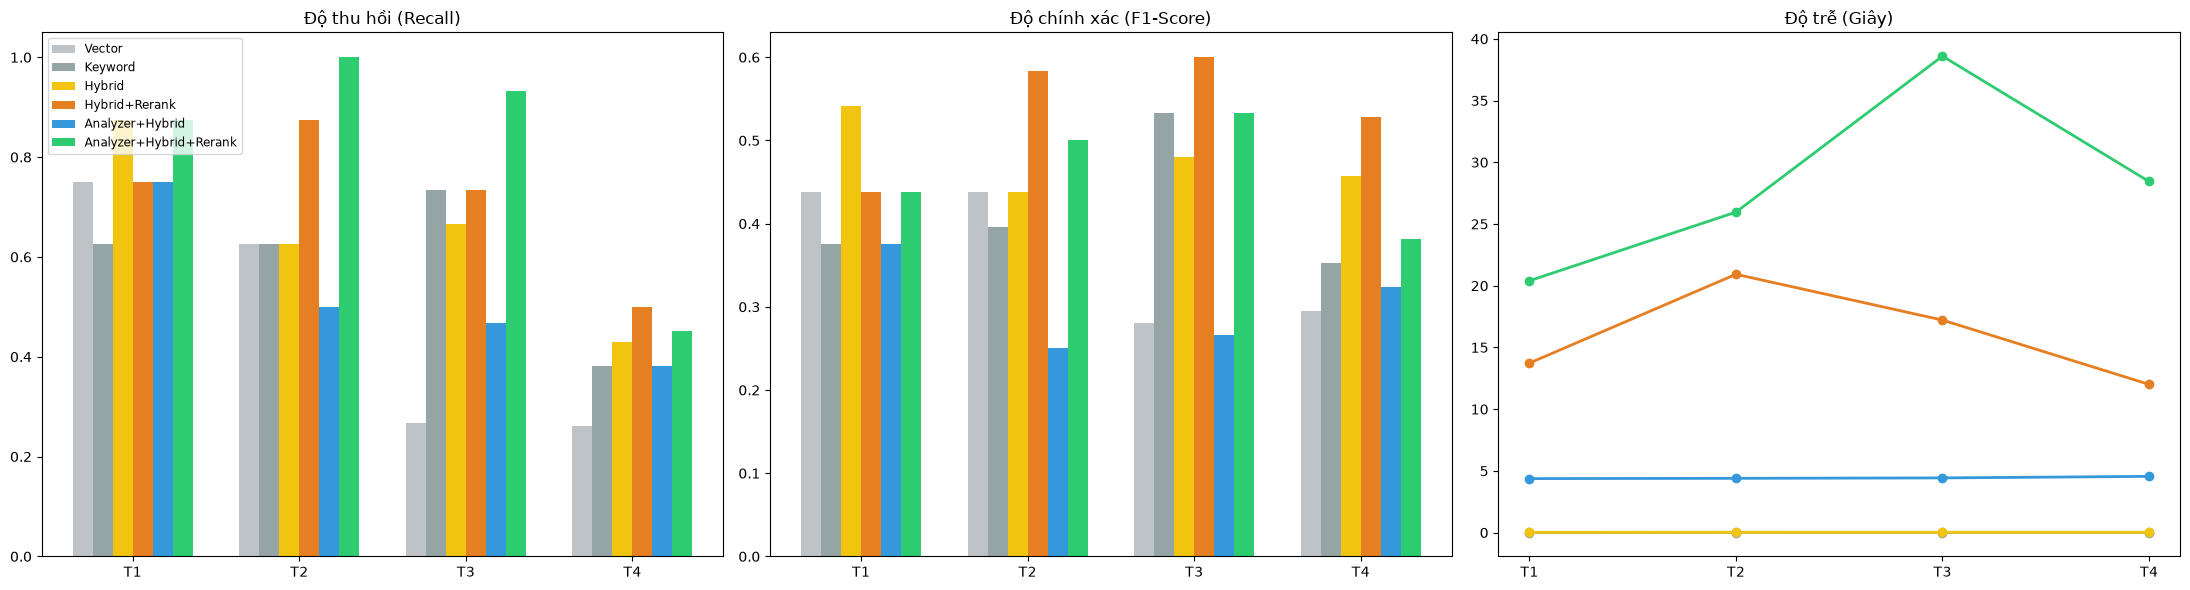

,Metric,Vector,Keyword,Hybrid (No Rerank),Hybrid + Rerank,Analyzer + Hybrid,Analyzer + Hybrid + Rerank
0,Recall,0.506,0.583,0.655,0.720,0.536,0.815
1,F1-Score,0.374,0.404,0.480,0.531,0.307,0.458
2,Latency(s),0.021,0.004,0.025,15.978,4.436,27.249


In [10]:
import matplotlib.pyplot as plt

with open('retrieval_experiment_logs_V4.json', 'r', encoding='utf-8') as f:
    logs = json.load(f)

def calc_metrics(exp_str, ret_list):
    exp_set = set([url.strip() for url in str(exp_str).split(',')])
    ret_set = set([url.strip() for url in ret_list])
    tp = len(exp_set.intersection(ret_set))
    fp = len(ret_set - exp_set)
    fn = len(exp_set - ret_set)
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
    return r, f1

results = []
for log in logs:
    exp = log['expected_urls']
    b1_r, b1_f1 = calc_metrics(exp, log['b1']['urls'])
    b2_r, b2_f1 = calc_metrics(exp, log['b2']['urls'])
    b3_r, b3_f1 = calc_metrics(exp, log['b3']['urls'])
    b4_r, b4_f1 = calc_metrics(exp, log['b4']['urls'])
    b5_r, b5_f1 = calc_metrics(exp, log['b5']['urls'])
    b6_r, b6_f1 = calc_metrics(exp, log['b6']['urls'])
    
    results.append({
        'Tier': log['true_tier'],
        'B1_R': b1_r, 'B1_F1': b1_f1, 'B1_Lat': log['b1']['latency'],
        'B2_R': b2_r, 'B2_F1': b2_f1, 'B2_Lat': log['b2']['latency'],
        'B3_R': b3_r, 'B3_F1': b3_f1, 'B3_Lat': log['b3']['latency'],
        'B4_R': b4_r, 'B4_F1': b4_f1, 'B4_Lat': log['b4']['latency'],
        'B5_R': b5_r, 'B5_F1': b5_f1, 'B5_Lat': log['b5']['latency'],
        'B6_R': b6_r, 'B6_F1': b6_f1, 'B6_Lat': log['b6']['latency']
    })

df = pd.DataFrame(results)
summary = df.groupby('Tier').mean().reset_index()

# TRỰC QUAN HÓA 6 CHIẾN LƯỢC
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
x = np.arange(len(summary['Tier']))
w = 0.12 # Thu hẹp độ rộng cột để nhét vừa 6 cột

colors = ['#bdc3c7', '#95a5a6', '#f1c40f', '#e67e22', '#3498db', '#2ecc71']
labels = ['Vector', 'Keyword', 'Hybrid', 'Hybrid+Rerank', 'Analyzer+Hybrid', 'Analyzer+Hybrid+Rerank']

# 1: Recall
for i, col in enumerate(['B1_R', 'B2_R', 'B3_R', 'B4_R', 'B5_R', 'B6_R']):
    axes[0].bar(x + (i-2.5)*w, summary[col], w, label=labels[i], color=colors[i])
axes[0].set_title('Độ thu hồi (Recall)'); axes[0].set_xticks(x); axes[0].set_xticklabels(['T1', 'T2', 'T3', 'T4'])
axes[0].legend(fontsize='small', loc='upper left')

# 2: F1-Score
for i, col in enumerate(['B1_F1', 'B2_F1', 'B3_F1', 'B4_F1', 'B5_F1', 'B6_F1']):
    axes[1].bar(x + (i-2.5)*w, summary[col], w, label=labels[i], color=colors[i])
axes[1].set_title('Độ chính xác (F1-Score)'); axes[1].set_xticks(x); axes[1].set_xticklabels(['T1', 'T2', 'T3', 'T4'])

# 3: Latency
for i, col in enumerate(['B1_Lat', 'B2_Lat', 'B3_Lat', 'B4_Lat', 'B5_Lat', 'B6_Lat']):
    axes[2].plot(x, summary[col], marker='o', label=labels[i], color=colors[i], linewidth=2)
axes[2].set_title('Độ trễ (Giây)'); axes[2].set_xticks(x); axes[2].set_xticklabels(['T1', 'T2', 'T3', 'T4'])

plt.tight_layout()
plt.show()

# BẢNG TỔNG QUÁT 6 CHIẾN LƯỢC
overall = pd.DataFrame({
    'Metric': ['Recall', 'F1-Score', 'Latency(s)'],
    'Vector': [df['B1_R'].mean(), df['B1_F1'].mean(), df['B1_Lat'].mean()],
    'Keyword': [df['B2_R'].mean(), df['B2_F1'].mean(), df['B2_Lat'].mean()],
    'Hybrid (No Rerank)': [df['B3_R'].mean(), df['B3_F1'].mean(), df['B3_Lat'].mean()],
    'Hybrid + Rerank': [df['B4_R'].mean(), df['B4_F1'].mean(), df['B4_Lat'].mean()],
    'Analyzer + Hybrid': [df['B5_R'].mean(), df['B5_F1'].mean(), df['B5_Lat'].mean()],
    'Analyzer + Hybrid + Rerank': [df['B6_R'].mean(), df['B6_F1'].mean(), df['B6_Lat'].mean()]
})
display(overall.round(3))

ví dụ giải thít thuật toán alpha và dung hợp nghịc đảo thứ hạng(RRF) trong hybrid Retrieval

In [1]:
def calculate_rrf(ranked_lists, k=60):
    """
    Tính toán điểm RRF cho các tài liệu từ nhiều danh sách xếp hạng.
    
    :param ranked_lists: List chứa các danh sách kết quả (mỗi danh sách là một list các document ID)
    :param k: Hằng số làm mịn (mặc định 60)
    :return: List các tuple (document_id, rrf_score) đã được sắp xếp giảm dần
    """
    rrf_scores = {}
    
    # Duyệt qua từng hệ thống truy xuất (VD: list của BM25, list của Vector)
    for ranked_list in ranked_lists:
        # enumerate(..., start=1) để lấy thứ hạng (rank) bắt đầu từ 1
        for rank, doc_id in enumerate(ranked_list, start=1):
            if doc_id not in rrf_scores:
                rrf_scores[doc_id] = 0.0
            
            # Cộng dồn điểm RRF từ hệ thống hiện tại
            rrf_scores[doc_id] += 1.0 / (k + rank)
            
    # Sắp xếp kết quả theo tổng điểm RRF từ cao xuống thấp
    sorted_results = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_results

# ==========================================
# MÔ PHỎNG DỮ LIỆU ĐẦU VÀO
# ==========================================

# Danh sách từ BM25: Tài liệu A đứng hạng 1, Tài liệu B đứng hạng 3
bm25_results = ["Tài liệu A", "Tài liệu C", "Tài liệu B", "Tài liệu D"]

# Danh sách từ Vector Search: Tài liệu B đứng hạng 4, Tài liệu A tuột xuống hạng 100
# (Tạo một danh sách giả lập với Tài liệu A ở vị trí 100)
vector_results = ["Tài liệu X", "Tài liệu Y", "Tài liệu Z", "Tài liệu B"] 
vector_results += [f"Tài liệu rác {i}" for i in range(5, 100)] 
vector_results.append("Tài liệu A")

# ==========================================
# CHẠY THUẬT TOÁN VÀ IN KẾT QUẢ
# ==========================================

final_ranking = calculate_rrf([bm25_results, vector_results], k=60)

print("BẢNG XẾP HẠNG RRF CUỐI CÙNG:")
print("-" * 40)
# Chỉ in ra Top 3 để dễ quan sát
for rank, (doc_id, score) in enumerate(final_ranking[:3], start=1):
    print(f"Hạng {rank}: {doc_id} (Điểm RRF: {score:.5f})")

BẢNG XẾP HẠNG RRF CUỐI CÙNG:
----------------------------------------
Hạng 1: Tài liệu B (Điểm RRF: 0.03150)
Hạng 2: Tài liệu A (Điểm RRF: 0.02264)
Hạng 3: Tài liệu X (Điểm RRF: 0.01639)


In [2]:
def min_max_normalize(scores_dict):
    """
    Chuẩn hóa các điểm số về khoảng [0, 1] bằng Min-Max Scaling.
    """
    if not scores_dict:
        return {}
    
    min_val = min(scores_dict.values())
    max_val = max(scores_dict.values())
    
    # Tránh lỗi chia cho 0 nếu tất cả điểm số đều bằng nhau
    if max_val == min_val:
        return {doc_id: 1.0 for doc_id in scores_dict}
        
    normalized = {}
    for doc_id, score in scores_dict.items():
        normalized[doc_id] = (score - min_val) / (max_val - min_val)
        
    return normalized

def calculate_alpha_fusion(bm25_scores, vector_scores, alpha):
    """
    Tính điểm dung hợp theo công thức: 
    Score = alpha * Vector_Score + (1 - alpha) * BM25_Score
    """
    # 1. Chuẩn hóa điểm của từng hệ thống độc lập
    norm_bm25 = min_max_normalize(bm25_scores)
    norm_vector = min_max_normalize(vector_scores)
    
    # 2. Tập hợp tất cả ID tài liệu
    all_docs = set(norm_bm25.keys()) | set(norm_vector.keys())
    
    final_scores = {}
    for doc_id in all_docs:
        # Nếu tài liệu không xuất hiện ở một hệ thống, cho điểm chuẩn hóa = 0
        s_bm25 = norm_bm25.get(doc_id, 0.0)
        s_vector = norm_vector.get(doc_id, 0.0)
        
        # 3. Tính toán theo trọng số alpha
        final_scores[doc_id] = alpha * s_vector + (1 - alpha) * s_bm25
        
    # 4. Sắp xếp giảm dần theo điểm tổng hợp
    return sorted(final_scores.items(), key=lambda x: x[1], reverse=True)

# ==========================================
# MÔ PHỎNG DỮ LIỆU ĐẦU VÀO (Điểm số thô)
# ==========================================
# BM25: Tài liệu A rất cao do khớp chính xác từng keyword
raw_bm25_scores = {
    "Tài liệu A": 25.5,  # Điểm rất cao
    "Tài liệu B": 5.2,   # Điểm thấp
    "Tài liệu C": 12.0
}

# Vector (Cosine Similarity): Tài liệu B rất cao do khớp ngữ nghĩa
raw_vector_scores = {
    "Tài liệu A": 0.35,  # Không khớp ngữ nghĩa
    "Tài liệu B": 0.88,  # Khớp ngữ nghĩa tốt
    "Tài liệu C": 0.50
}

# ==========================================
# CHẠY THỬ NGHIỆM VỚI CÁC HỆ SỐ ALPHA KHÁC NHAU
# ==========================================

print("--- KỊCH BẢN 1: alpha = 0.2 (ƯU TIÊN BM25 / TỪ KHÓA) ---")
# alpha = 0.2 nghĩa là 20% Vector + 80% BM25
results_keyword_focused = calculate_alpha_fusion(raw_bm25_scores, raw_vector_scores, alpha=0.2)
for rank, (doc, score) in enumerate(results_keyword_focused, 1):
    print(f"Hạng {rank}: {doc} (Điểm Alpha: {score:.3f})")

print("\n--- KỊCH BẢN 2: alpha = 0.8 (ƯU TIÊN VECTOR / NGỮ NGHĨA) ---")
# alpha = 0.8 nghĩa là 80% Vector + 20% BM25
results_semantic_focused = calculate_alpha_fusion(raw_bm25_scores, raw_vector_scores, alpha=0.8)
for rank, (doc, score) in enumerate(results_semantic_focused, 1):
    print(f"Hạng {rank}: {doc} (Điểm Alpha: {score:.3f})")

--- KỊCH BẢN 1: alpha = 0.2 (ƯU TIÊN BM25 / TỪ KHÓA) ---
Hạng 1: Tài liệu A (Điểm Alpha: 0.800)
Hạng 2: Tài liệu C (Điểm Alpha: 0.325)
Hạng 3: Tài liệu B (Điểm Alpha: 0.200)

--- KỊCH BẢN 2: alpha = 0.8 (ƯU TIÊN VECTOR / NGỮ NGHĨA) ---
Hạng 1: Tài liệu B (Điểm Alpha: 0.800)
Hạng 2: Tài liệu C (Điểm Alpha: 0.293)
Hạng 3: Tài liệu A (Điểm Alpha: 0.200)
